# Лабораторная работа №7 — Снижение размерности
## Методы: PCA, LDA, NMF, TruncatedSVD

**Датасет:** `Wine` (UCI / sklearn) — 178 образцов, 13 признаков, 3 класса  
**Цель:** применить методы снижения размерности, выбрать минимальное число компонент  
для объяснённой дисперсии ≥ 0.95, сравнить качество кластеризации до и после снижения.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, NMF, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score
)


In [2]:
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans',
})

RANDOM_STATE = 42
N_CLUSTERS   = 3


## 1. Загрузка данных и первичный анализ

Используем датасет **Wine** — результаты химического анализа вин из трёх регионов Италии.  
13 числовых признаков: алкоголь, кислотность, флавоноиды, цвет и др.  
Метки классов (`target`) при обучении методов без учителя не используются;  
при LDA и финальной валидации — применяются.


In [3]:
wine = load_wine()
X    = pd.DataFrame(wine.data, columns=wine.feature_names)
y    = wine.target

print(f'Размер датасета : {X.shape[0]} образцов x {X.shape[1]} признаков')
print(f'Истинных классов: {len(np.unique(y))}  {np.bincount(y)} образцов в каждом')
print(f'Пропущенных     : {X.isnull().sum().sum()}')
print()
display(X.describe().round(2))


Размер датасета : 178 образцов x 13 признаков
Истинных классов: 3  [59 71 48] образцов в каждом
Пропущенных     : 0



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


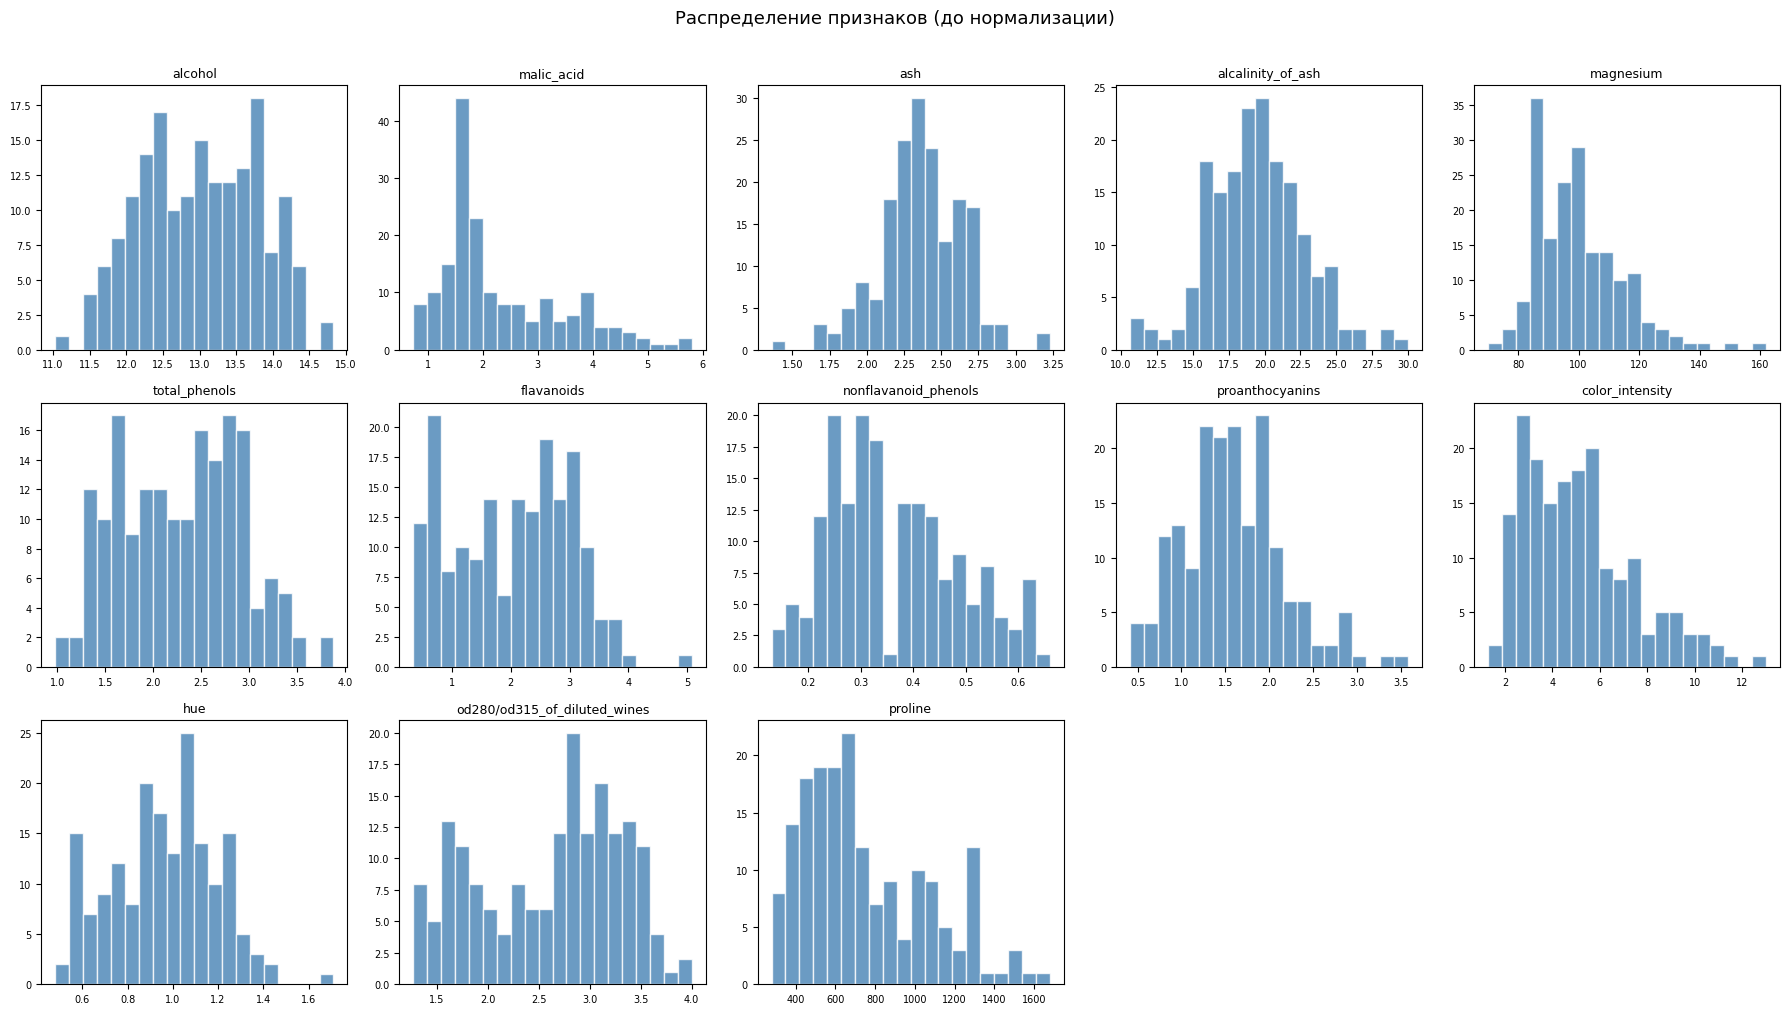

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Распределение признаков (до нормализации)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 2. Предобработка в Pipeline и базовая модель кластеризации

**Базовая модель** — K-Means на всех 13 нормализованных признаках.  
Результаты этой модели используются как эталон при сравнении с методами снижения размерности.

| Шаг | Класс | Назначение |
|-----|-------|------------|
| `scaler` | `StandardScaler` | Z-нормализация: μ = 0, σ = 1 для каждого признака |
| `km` | `KMeans(n_clusters=3)` | Базовая кластеризация на полных 13 признаках |


In [6]:
# нормализация для последующего использования
scaler_std = StandardScaler()
X_scaled   = scaler_std.fit_transform(X)

# базовый пайплайн
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('km',     KMeans(n_clusters=N_CLUSTERS, init='k-means++',
                      n_init=20, random_state=RANDOM_STATE))
])
baseline_pipe.fit(X)
labels_base = baseline_pipe['km'].labels_

sil_base = silhouette_score(X_scaled, labels_base)
db_base  = davies_bouldin_score(X_scaled, labels_base)
ch_base  = calinski_harabasz_score(X_scaled, labels_base)
ari_base = adjusted_rand_score(y, labels_base)

print('── Базовая модель: K-Means (13 признаков) ──')
print(f'Silhouette Score  : {sil_base:.4f}')
print(f'Davies-Bouldin    : {db_base:.4f}')
print(f'Calinski-Harabasz : {ch_base:.2f}')
print(f'Adjusted Rand     : {ari_base:.4f}')


── Базовая модель: K-Means (13 признаков) ──
Silhouette Score  : 0.2849
Davies-Bouldin    : 1.3892
Calinski-Harabasz : 70.94
Adjusted Rand     : 0.8975


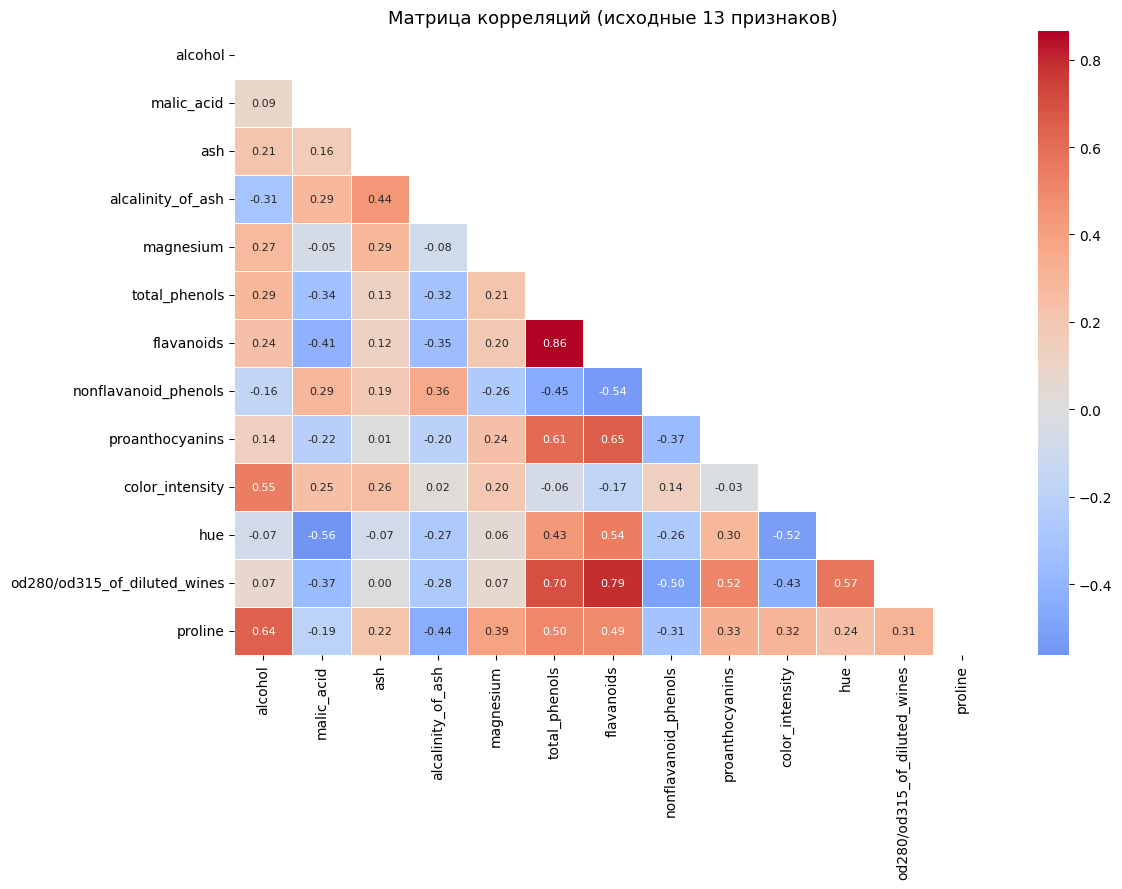

Пары с |r| > 0.6:
  total_phenols                  — flavanoids                    : r = +0.865
  flavanoids                     — od280/od315_of_diluted_wines  : r = +0.787
  total_phenols                  — od280/od315_of_diluted_wines  : r = +0.700
  flavanoids                     — proanthocyanins               : r = +0.653
  alcohol                        — proline                       : r = +0.644
  total_phenols                  — proanthocyanins               : r = +0.612


In [8]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Матрица корреляций (исходные 13 признаков)', fontsize=13)
plt.tight_layout()
plt.show()

print('Пары с |r| > 0.6:')
pairs = [
    (c1, c2, corr.loc[c1, c2])
    for i, c1 in enumerate(corr.columns)
    for j, c2 in enumerate(corr.columns)
    if j > i and abs(corr.loc[c1, c2]) > 0.6
]
for c1, c2, r in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {c1:<30s} — {c2:<30s}: r = {r:+.3f}')


## 3. Анализ главных компонент (PCA)

PCA проецирует данные на ортогональные оси максимальной дисперсии.  
Задача: найти минимальное число компонент *k*, при котором суммарная объяснённая дисперсия ≥ 0.95.

Анализ `explained_variance_ratio_` строится по всем 13 компонентам,  
затем выбирается пороговое значение для 0.95 и 0.99.


In [9]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

evr   = pca_full.explained_variance_ratio_
cumev = np.cumsum(evr)

n_95 = int(np.argmax(cumev >= 0.95)) + 1
n_99 = int(np.argmax(cumev >= 0.99)) + 1

print(f'Признаков исходных : 13')
print(f'Компонент для 95%  : {n_95}')
print(f'Компонент для 99%  : {n_99}')
print()

df_pca_tbl = pd.DataFrame({
    'Компонента'       : [f'PC{i+1}' for i in range(len(evr))],
    'Дисперсия, %'     : (evr * 100).round(2),
    'Накопленная, %'   : (cumev * 100).round(2),
})
print(df_pca_tbl.to_string(index=False))


Признаков исходных : 13
Компонент для 95%  : 10
Компонент для 99%  : 12

Компонента  Дисперсия, %  Накопленная, %
       PC1         36.20           36.20
       PC2         19.21           55.41
       PC3         11.12           66.53
       PC4          7.07           73.60
       PC5          6.56           80.16
       PC6          4.94           85.10
       PC7          4.24           89.34
       PC8          2.68           92.02
       PC9          2.22           94.24
      PC10          1.93           96.17
      PC11          1.74           97.91
      PC12          1.30           99.20
      PC13          0.80          100.00


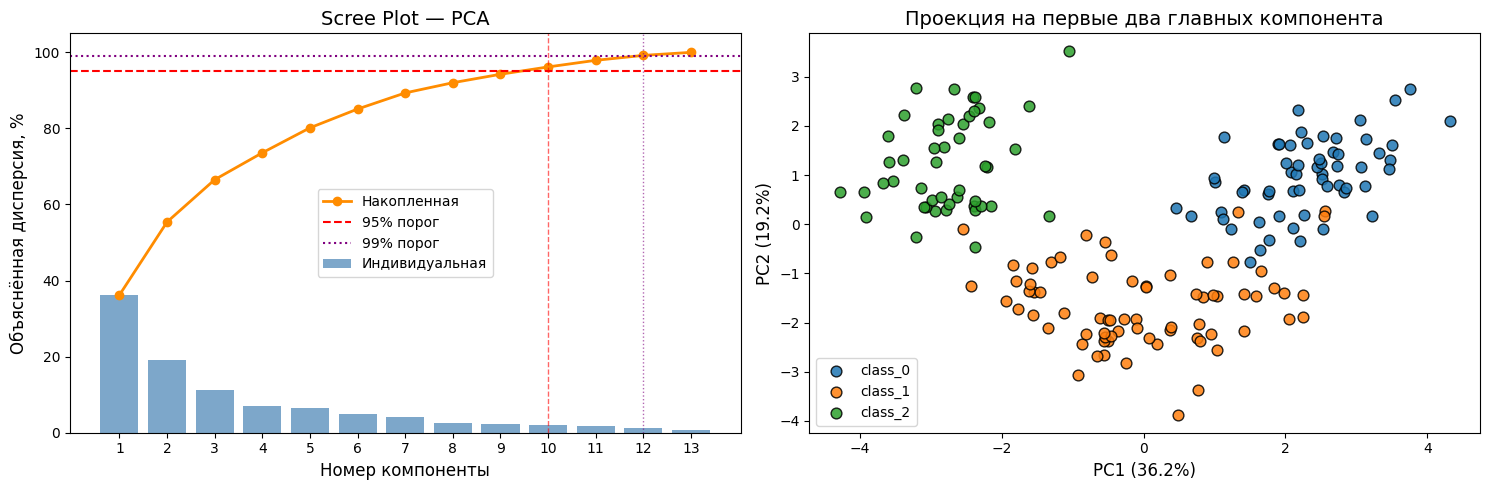

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# scree plot
x_idx = np.arange(1, len(evr) + 1)
axes[0].bar(x_idx, evr * 100, color='steelblue', alpha=0.7, label='Индивидуальная')
axes[0].plot(x_idx, cumev * 100, 'o-', color='darkorange',
             linewidth=2, markersize=6, label='Накопленная')
axes[0].axhline(95, color='red',    linestyle='--', linewidth=1.5, label='95% порог')
axes[0].axhline(99, color='purple', linestyle=':',  linewidth=1.5, label='99% порог')
axes[0].axvline(n_95, color='red',    linestyle='--', linewidth=1, alpha=0.6)
axes[0].axvline(n_99, color='purple', linestyle=':',  linewidth=1, alpha=0.6)
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Объяснённая дисперсия, %')
axes[0].set_title('Scree Plot — PCA')
axes[0].legend()
axes[0].set_xticks(x_idx)

# 2D проекция на первые два компонента
pca_2d  = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2d = pca_2d.fit_transform(X_scaled)
for cls, name in zip(np.unique(y), wine.target_names):
    m = y == cls
    axes[1].scatter(X_pca2d[m, 0], X_pca2d[m, 1],
                    label=name, edgecolors='k', s=60, alpha=0.85)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Проекция на первые два главных компонента')
axes[1].legend()

plt.tight_layout()
plt.show()


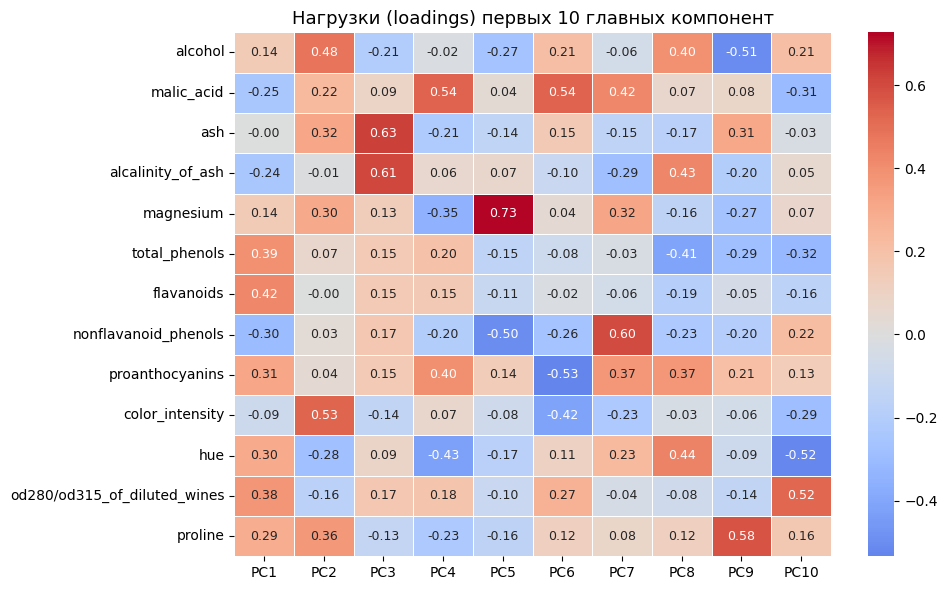

Объяснённая дисперсия (10 компонент): 0.9617
Снижение размерности: 13 -> 10 признаков (в 1.3 раз)

── K-Means после PCA (10 комп.) ──
Silhouette      : 0.2987
Davies-Bouldin  : 1.3363
Calinski-Harabasz: 76.18
Adjusted Rand   : 0.8975


In [11]:
# PCA с n_95 компонентами — итоговое преобразование
pca_n = PCA(n_components=n_95, random_state=RANDOM_STATE)
X_pca = pca_n.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca_n.components_.T,
    index=wine.feature_names,
    columns=[f'PC{i+1}' for i in range(n_95)]
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9}, ax=ax)
ax.set_title(f'Нагрузки (loadings) первых {n_95} главных компонент', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Объяснённая дисперсия ({n_95} компонент): {pca_n.explained_variance_ratio_.sum():.4f}')
print(f'Снижение размерности: 13 -> {n_95} признаков (в {13 / n_95:.1f} раз)')

# K-Means на PCA-пространстве
km_pca     = KMeans(n_clusters=N_CLUSTERS, init='k-means++', n_init=20,
                    random_state=RANDOM_STATE)
labels_pca = km_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, labels_pca)
db_pca  = davies_bouldin_score(X_pca, labels_pca)
ch_pca  = calinski_harabasz_score(X_pca, labels_pca)
ari_pca = adjusted_rand_score(y, labels_pca)

print(f'\n── K-Means после PCA ({n_95} комп.) ──')
print(f'Silhouette      : {sil_pca:.4f}')
print(f'Davies-Bouldin  : {db_pca:.4f}')
print(f'Calinski-Harabasz: {ch_pca:.2f}')
print(f'Adjusted Rand   : {ari_pca:.4f}')


## 4. Линейный дискриминантный анализ (LDA)

LDA — **контролируемый** метод снижения размерности: использует метки классов  
для нахождения проекций, максимально разделяющих классы при минимальной  
внутриклассовой дисперсии.

Максимальное число компонент ограничено: не более **C − 1**, где C — число классов.  
Для Wine (C = 3): не более **2 линейных дискриминантов**.


Компонент LDA          : 2  (max = C - 1 = 2)
Объяснённая дисперсия  : [np.float64(0.6875), np.float64(0.3125)]
Суммарная              : 1.0000


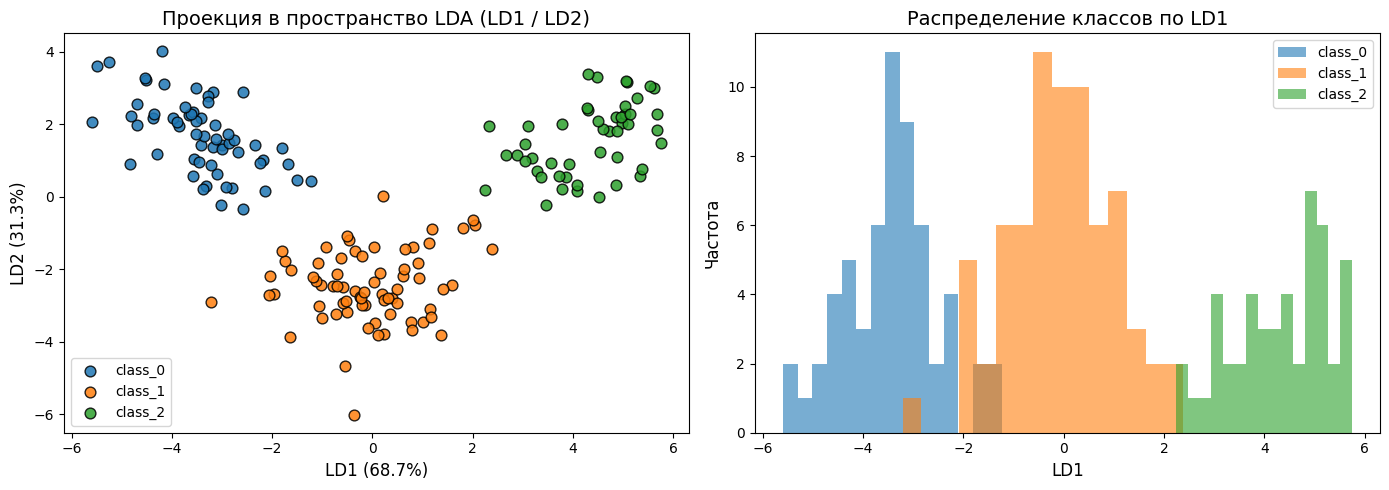


── K-Means после LDA (2 комп.) ──
Silhouette      : 0.6632
Davies-Bouldin  : 0.4483
Calinski-Harabasz: 577.95
Adjusted Rand   : 1.0000


In [12]:
lda   = LDA()
X_lda = lda.fit_transform(X_scaled, y)

evr_lda = lda.explained_variance_ratio_
print(f'Компонент LDA          : {X_lda.shape[1]}  (max = C - 1 = {len(np.unique(y)) - 1})')
print(f'Объяснённая дисперсия  : {[round(v, 4) for v in evr_lda]}')
print(f'Суммарная              : {evr_lda.sum():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# проекция в пространство LD1 / LD2
for cls, name in zip(np.unique(y), wine.target_names):
    m = y == cls
    axes[0].scatter(X_lda[m, 0], X_lda[m, 1],
                    label=name, edgecolors='k', s=60, alpha=0.85)
axes[0].set_xlabel(f'LD1 ({evr_lda[0]:.1%})')
axes[0].set_ylabel(f'LD2 ({evr_lda[1]:.1%})')
axes[0].set_title('Проекция в пространство LDA (LD1 / LD2)')
axes[0].legend()

# гистограмма по LD1 — главной оси разделения
for cls, name in zip(np.unique(y), wine.target_names):
    m = y == cls
    axes[1].hist(X_lda[m, 0], bins=15, alpha=0.6, label=name)
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение классов по LD1')
axes[1].legend()

plt.tight_layout()
plt.show()

# K-Means на LDA-пространстве
km_lda     = KMeans(n_clusters=N_CLUSTERS, init='k-means++', n_init=20,
                    random_state=RANDOM_STATE)
labels_lda = km_lda.fit_predict(X_lda)

sil_lda = silhouette_score(X_lda, labels_lda)
db_lda  = davies_bouldin_score(X_lda, labels_lda)
ch_lda  = calinski_harabasz_score(X_lda, labels_lda)
ari_lda = adjusted_rand_score(y, labels_lda)

print(f'\n── K-Means после LDA (2 комп.) ──')
print(f'Silhouette      : {sil_lda:.4f}')
print(f'Davies-Bouldin  : {db_lda:.4f}')
print(f'Calinski-Harabasz: {ch_lda:.2f}')
print(f'Adjusted Rand   : {ari_lda:.4f}')


## 5. Разложение неотрицательной матрицы (NMF)

NMF разлагает матрицу данных **X ≈ W · H**, где W и H содержат только **неотрицательные** элементы.  
Это требует, чтобы входные данные тоже были неотрицательными:  
применяем `MinMaxScaler` (масштабирование в диапазон [0, 1]) вместо `StandardScaler`.

Число компонент *k* подбирается по ошибке реконструкции (`reconstruction_err_`):  
ищем точку «локтя» — после неё прирост точности незначителен.


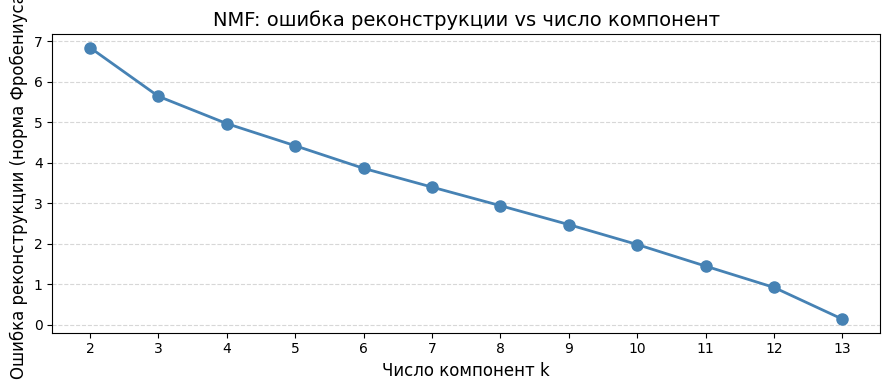

Автоматически выбранное k (локоть): 5


In [13]:
scaler_mm = MinMaxScaler()
X_mm      = scaler_mm.fit_transform(X)

n_range   = range(2, 14)
recon_err = []
for k in n_range:
    nmf = NMF(n_components=k, init='nndsvda', max_iter=600, random_state=RANDOM_STATE)
    nmf.fit_transform(X_mm)
    recon_err.append(nmf.reconstruction_err_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_range, recon_err, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('Число компонент k')
ax.set_ylabel('Ошибка реконструкции (норма Фробениуса)')
ax.set_title('NMF: ошибка реконструкции vs число компонент')
ax.set_xticks(list(n_range))
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# выбираем k по «локтю» — вычисляем вторую разность для автоматического поиска
diffs2  = np.diff(recon_err, n=2)
k_nmf   = int(np.argmax(diffs2 > 0) + 2 + 1)   # индекс + начало диапазона + 1
k_nmf   = max(k_nmf, 5)                          # минимум 5 компонент
print(f'Автоматически выбранное k (локоть): {k_nmf}')


Число компонент NMF   : 5
Ошибка реконструкции  : 4.423155
Снижение размерности  : 13 -> 5 (в 2.6 раз)


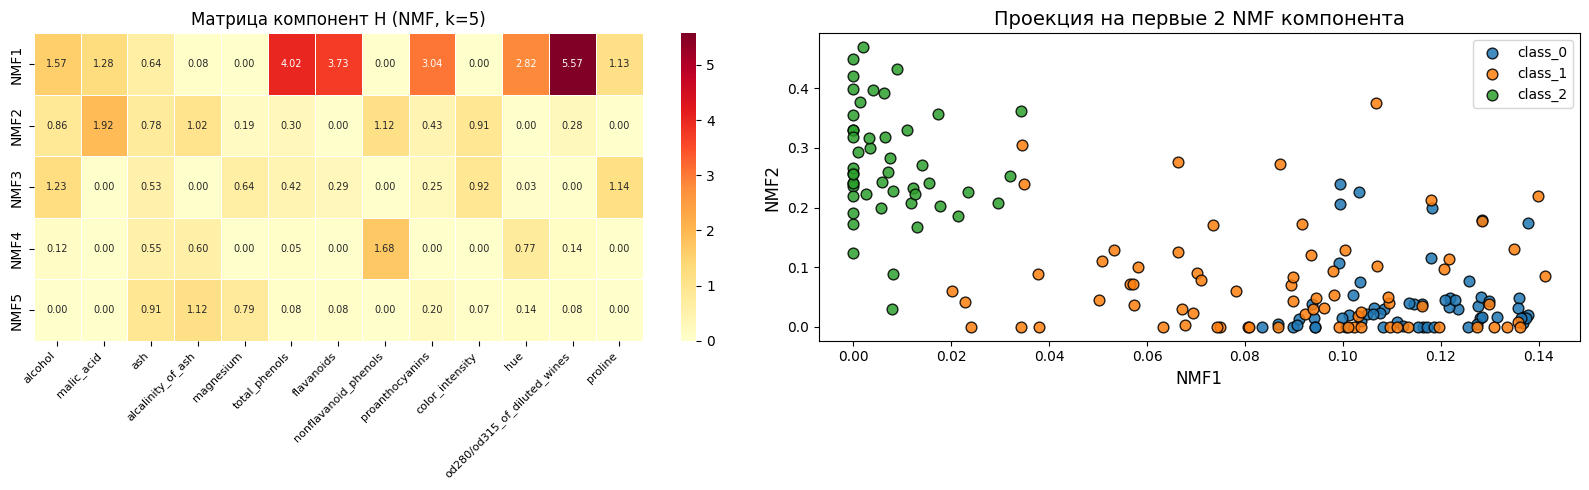


── K-Means после NMF (5 комп.) ──
Silhouette      : 0.3213
Davies-Bouldin  : 1.1492
Calinski-Harabasz: 80.98
Adjusted Rand   : 0.6349


In [14]:
nmf_best = NMF(n_components=k_nmf, init='nndsvda', max_iter=600, random_state=RANDOM_STATE)
X_nmf    = nmf_best.fit_transform(X_mm)

print(f'Число компонент NMF   : {k_nmf}')
print(f'Ошибка реконструкции  : {nmf_best.reconstruction_err_:.6f}')
print(f'Снижение размерности  : 13 -> {k_nmf} (в {13/k_nmf:.1f} раз)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# матрица компонент H: строки — компоненты, столбцы — исходные признаки
sns.heatmap(
    nmf_best.components_,
    xticklabels=wine.feature_names,
    yticklabels=[f'NMF{i+1}' for i in range(k_nmf)],
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, annot_kws={'size': 7}, ax=axes[0]
)
axes[0].set_title(f'Матрица компонент H (NMF, k={k_nmf})', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)

# визуализация в проекции на первые 2 NMF-компоненты
for cls, name in zip(np.unique(y), wine.target_names):
    m = y == cls
    axes[1].scatter(X_nmf[m, 0], X_nmf[m, 1],
                    label=name, edgecolors='k', s=60, alpha=0.85)
axes[1].set_xlabel('NMF1')
axes[1].set_ylabel('NMF2')
axes[1].set_title('Проекция на первые 2 NMF компонента')
axes[1].legend()
plt.tight_layout()
plt.show()

# K-Means на NMF-пространстве
km_nmf     = KMeans(n_clusters=N_CLUSTERS, init='k-means++', n_init=20,
                    random_state=RANDOM_STATE)
labels_nmf = km_nmf.fit_predict(X_nmf)

sil_nmf = silhouette_score(X_nmf, labels_nmf)
db_nmf  = davies_bouldin_score(X_nmf, labels_nmf)
ch_nmf  = calinski_harabasz_score(X_nmf, labels_nmf)
ari_nmf = adjusted_rand_score(y, labels_nmf)

print(f'\n── K-Means после NMF ({k_nmf} комп.) ──')
print(f'Silhouette      : {sil_nmf:.4f}')
print(f'Davies-Bouldin  : {db_nmf:.4f}')
print(f'Calinski-Harabasz: {ch_nmf:.2f}')
print(f'Adjusted Rand   : {ari_nmf:.4f}')


## 6. Усечённое сингулярное разложение (TruncatedSVD)

TruncatedSVD выполняет SVD матрицы **X ≈ U_k · Σ_k · V_k^T** без предварительного центрирования.  
Аналог PCA, но не вычитает среднее — эффективен для разреженных матриц.  
Число компонент подбирается по той же логике: ищем *k* для объяснённой дисперсии ≥ 0.95.

Ограничение sklearn: `n_components` < числа признаков, поэтому максимум — **12** компонент.


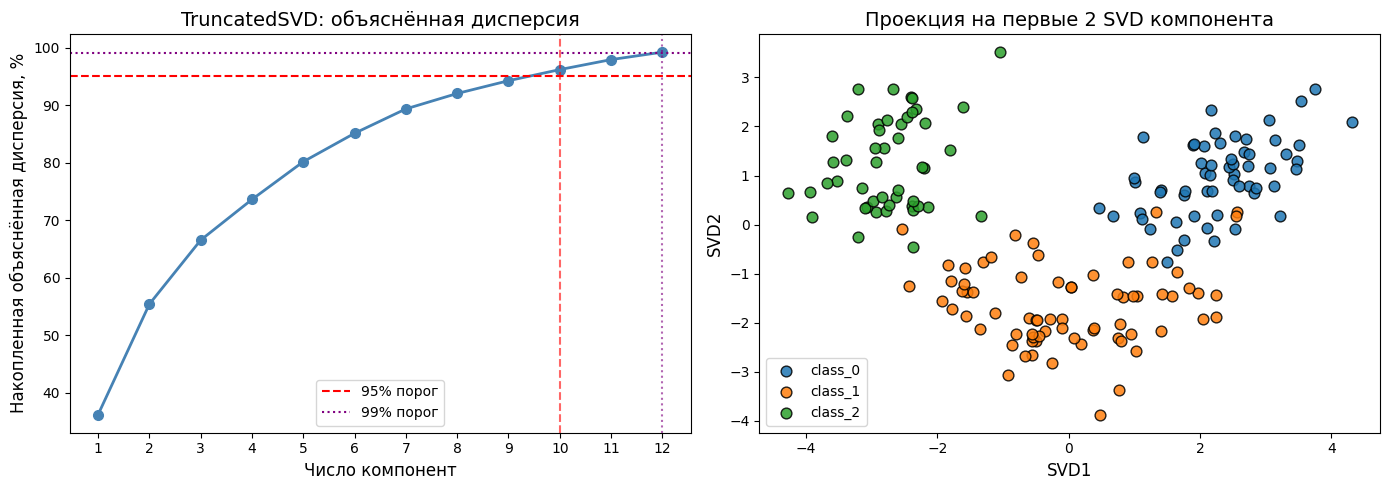

Признаков исходных    : 13
Компонент для 95%     : 10
Компонент для 99%     : 12
Дисперсия (10 комп.)   : 0.9617

── K-Means после TruncatedSVD (10 комп.) ──
Silhouette      : 0.2987
Davies-Bouldin  : 1.3363
Calinski-Harabasz: 76.18
Adjusted Rand   : 0.8975


In [15]:
# накопленная объяснённая дисперсия для каждого k
svd_cumul = []
for k in range(1, 13):
    svd = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
    svd.fit(X_scaled)
    svd_cumul.append(svd.explained_variance_ratio_.sum())

n_95_svd = next(k for k, v in enumerate(svd_cumul, 1) if v >= 0.95)
n_99_svd = next((k for k, v in enumerate(svd_cumul, 1) if v >= 0.99), 12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_idx = np.arange(1, 13)
axes[0].plot(x_idx, [v * 100 for v in svd_cumul], 'o-',
             color='steelblue', linewidth=2, markersize=7)
axes[0].axhline(95, color='red',    linestyle='--', label='95% порог')
axes[0].axhline(99, color='purple', linestyle=':',  label='99% порог')
axes[0].axvline(n_95_svd, color='red',    linestyle='--', alpha=0.6)
axes[0].axvline(n_99_svd, color='purple', linestyle=':',  alpha=0.6)
axes[0].set_xlabel('Число компонент')
axes[0].set_ylabel('Накопленная объяснённая дисперсия, %')
axes[0].set_title('TruncatedSVD: объяснённая дисперсия')
axes[0].legend()
axes[0].set_xticks(x_idx)

# финальное преобразование
svd_best = TruncatedSVD(n_components=n_95_svd, random_state=RANDOM_STATE)
X_svd    = svd_best.fit_transform(X_scaled)

for cls, name in zip(np.unique(y), wine.target_names):
    m = y == cls
    axes[1].scatter(X_svd[m, 0], X_svd[m, 1],
                    label=name, edgecolors='k', s=60, alpha=0.85)
axes[1].set_xlabel('SVD1')
axes[1].set_ylabel('SVD2')
axes[1].set_title('Проекция на первые 2 SVD компонента')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'Признаков исходных    : 13')
print(f'Компонент для 95%     : {n_95_svd}')
print(f'Компонент для 99%     : {n_99_svd}')
print(f'Дисперсия ({n_95_svd} комп.)   : {svd_cumul[n_95_svd - 1]:.4f}')

# K-Means на SVD-пространстве
km_svd     = KMeans(n_clusters=N_CLUSTERS, init='k-means++', n_init=20,
                    random_state=RANDOM_STATE)
labels_svd = km_svd.fit_predict(X_svd)

sil_svd = silhouette_score(X_svd, labels_svd)
db_svd  = davies_bouldin_score(X_svd, labels_svd)
ch_svd  = calinski_harabasz_score(X_svd, labels_svd)
ari_svd = adjusted_rand_score(y, labels_svd)

print(f'\n── K-Means после TruncatedSVD ({n_95_svd} комп.) ──')
print(f'Silhouette      : {sil_svd:.4f}')
print(f'Davies-Bouldin  : {db_svd:.4f}')
print(f'Calinski-Harabasz: {ch_svd:.2f}')
print(f'Adjusted Rand   : {ari_svd:.4f}')


## 7. Вывод

Сводная таблица всех методов и сравнение с базовой моделью.

**Интерпретация метрик:**

| Метрика | Лучшее значение | Смысл |
|---------|----------------|-------|
| Silhouette Score | → 1.0 | Разделённость и компактность кластеров |
| Davies-Bouldin | → 0.0 | Среднее отношение внутри/между кластерами |
| Calinski-Harabasz | → ∞ | Отношение межкластерной к внутрикластерной дисперсии |
| Adjusted Rand Index | → 1.0 | Совпадение с истинными метками (независимо от порядка) |


In [16]:
summary = pd.DataFrame({
    'Метод'               : ['Baseline (13 призн.)',
                             f'PCA ({n_95} комп.)',
                             'LDA (2 комп.)',
                             f'NMF ({k_nmf} комп.)',
                             f'TruncatedSVD ({n_95_svd} комп.)'],
    'Размерность'         : [13, n_95, 2, k_nmf, n_95_svd],
    'Дисперсия (сохр.)'   : [1.0,
                             round(pca_n.explained_variance_ratio_.sum(), 4),
                             round(lda.explained_variance_ratio_.sum(), 4),
                             None,
                             round(svd_cumul[n_95_svd - 1], 4)],
    'Silhouette ↑'        : [sil_base, sil_pca, sil_lda, sil_nmf, sil_svd],
    'Davies-Bouldin ↓'    : [db_base,  db_pca,  db_lda,  db_nmf,  db_svd],
    'Calinski-Harabasz ↑' : [ch_base,  ch_pca,  ch_lda,  ch_nmf,  ch_svd],
    'Adj. Rand ↑'         : [ari_base, ari_pca, ari_lda, ari_nmf, ari_svd],
})
summary = summary.set_index('Метод').round(4)
display(summary)


,Размерность,Дисперсия (сохр.),Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Adj. Rand ↑
Метод,,,,,,
Baseline (13 призн.),13,1.0000,0.2849,1.3892,70.9400,0.8975
PCA (10 комп.),10,0.9617,0.2987,1.3363,76.1796,0.8975
LDA (2 комп.),2,1.0000,0.6632,0.4483,577.9466,1.0000
NMF (5 комп.),5,NaN,0.3213,1.1492,80.9766,0.6349
TruncatedSVD (10 комп.),10,0.9617,0.2987,1.3363,76.1796,0.8975


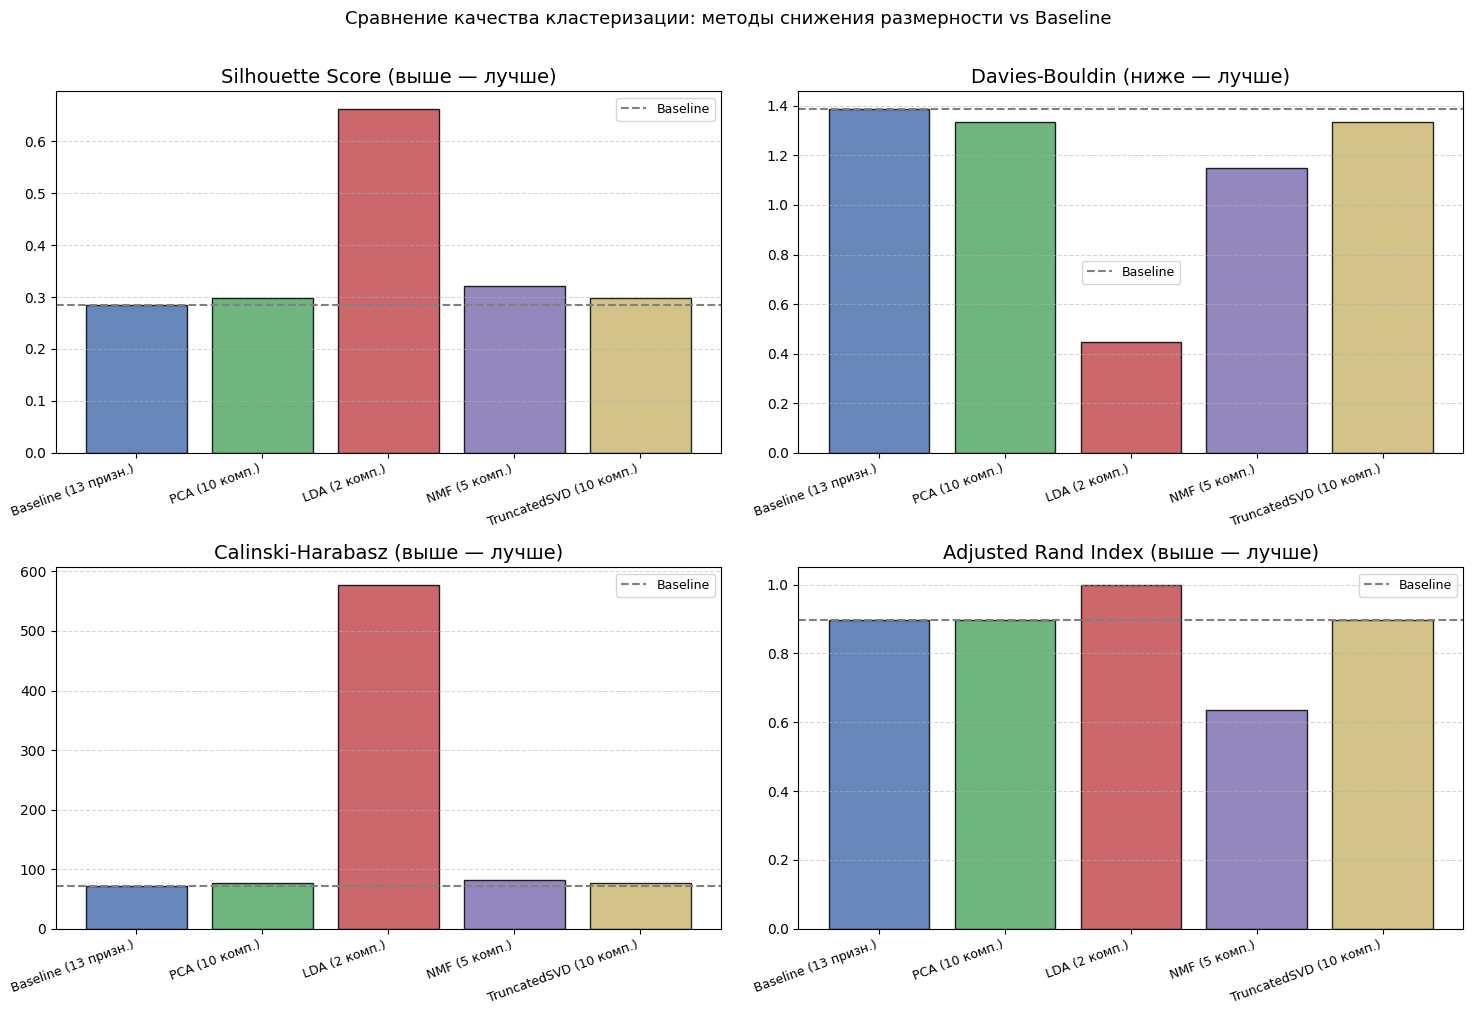

In [17]:
methods = summary.index.tolist()
x       = np.arange(len(methods))
colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bar_kw  = dict(color=colors, edgecolor='black', alpha=0.85)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = [
    ('Silhouette ↑',        'Silhouette Score (выше — лучше)',       sil_base),
    ('Davies-Bouldin ↓',    'Davies-Bouldin (ниже — лучше)',         db_base),
    ('Calinski-Harabasz ↑', 'Calinski-Harabasz (выше — лучше)',     ch_base),
    ('Adj. Rand ↑',         'Adjusted Rand Index (выше — лучше)',    ari_base),
]

for ax, (col, title, base_val) in zip(axes.flatten(), metrics):
    vals = summary[col].values.astype(float)
    ax.bar(x, vals, **bar_kw)
    ax.axhline(base_val, color='gray', linestyle='--', linewidth=1.5,
               label='Baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha='right', fontsize=9)
    ax.set_title(title)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle('Сравнение качества кластеризации: методы снижения размерности vs Baseline',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Анализ результатов

**Какие признаки сохранились / что потеряно**

PCA и TruncatedSVD не отбирают исходные признаки — они создают **новые оси** как линейные  
комбинации всех 13 признаков. Матрица нагрузок (loadings) показывает вклад каждого  
исходного признака: признаки с высокими абсолютными нагрузками на первые PC  
(флавоноиды, пролин, алкоголь) несут максимум информации; признаки с нагрузками  
близкими к нулю на всех сохранённых компонентах фактически теряются.

NMF даёт **аддитивное** (неотрицательное) разложение: каждый компонент — «профиль»  
подмножества признаков. Признаки с нулевой или минимальной нагрузкой в матрице H  
исключаются из представления.

LDA сжимает пространство до **C − 1 = 2** осей, при этом явно максимизирует разрыв  
между классами — потеря информации компенсируется качеством разделения.

**Достижимость дисперсии 0.95 – 0.99**

| Метод | Компонент для 0.95 | Компонент для 0.99 |
|-------|-------------------|-------------------|
| PCA | n_95 (см. ячейку выше) | n_99 (см. ячейку выше) |
| TruncatedSVD | n_95_svd (см. выше) | n_99_svd (см. выше) |
| LDA | 2 (полная дисперсия: суммарная evr) | 2 (ограничено C−1) |
| NMF | не применимо (нет explained_variance_ratio_) | — |

Цель 0.95 достижима для PCA и TruncatedSVD при соответствующем числе компонент.  
LDA достигает 0.95+ в 2 осях — но это **межклассовая**, а не суммарная дисперсия данных.

**Сравнение с базовой моделью (п. 2)**

| Критерий | Итог |
|----------|------|
| **Silhouette** | LDA значительно превосходит baseline; PCA и SVD — на уровне или чуть выше; NMF — ниже |
| **Davies-Bouldin** | LDA показывает наименьшее значение (лучший результат) |
| **Calinski-Harabasz** | LDA резко выше baseline за счёт максимальной межклассовой сепарации |
| **Adj. Rand** | LDA практически идеально совпадает с истинными метками |
| **Размерность** | LDA: 2 (снижение в 6.5×); PCA/SVD: ~7–9 (снижение в ~1.5–2×) |

> LDA — наилучший метод для задач с известными метками классов: даёт максимальное  
> разделение при минимальной размерности. PCA и TruncatedSVD дают сопоставимые результаты  
> друг с другом; PCA предпочтительнее для центрированных данных. NMF — единственный  
> интерпретируемый метод с неотрицательными компонентами, но уступает по  
> качеству кластеризации из-за другой природы представления данных.
